# 07 — Nos données terrain Hanoï

**Le maillon entre la collecte (ODK/Kobo) et le modèle (notebook 08).**

Ce notebook fait tout le travail sur NOS données :
1. Charge l'export CSV de KoboToolbox
2. Nettoie (même pipeline que le notebook 02 sur Sunbird)
3. Enrichit avec la météo (API Open-Meteo, gratuite)
4. Analyses de la Phase 3 du plan : time-series par site, transport vs chantier, dépassements de normes
5. Sauvegarde `data/raw/hanoi/measurements.csv` → consommé par le notebook 08

**Comment exporter depuis Kobo :** ton projet → Data → Downloads → CSV → place le fichier dans `data/raw/hanoi/`

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../scripts'))
import prepare_field_data as pfd   # source de vérité unique du nettoyage terrain

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charge l'export Kobo le plus récent → nettoyage + backfill + météo (cf. le script).
# Le brut Kobo n'est pas modifié ; tout le travail est en mémoire.
df = pfd.build_dataframe()
print(f'{len(df)} mesures propres — sites : {df["site"].value_counts().to_dict()}')
df[['timestamp', 'site', 'collector', 'noise_dB', 'dist_to_road', 'mic_to_source']].head()

/Users/phocidae/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


220 mesures propres — sites : {'Ocean Park': 148, 'Hoan Kiem lake': 44, 'Vinh Tuy area': 28}


,timestamp,site,collector,noise_dB,dist_to_road,mic_to_source
0,2026-06-10 14:33:42.770,Ocean Park,lucas,75.0,0-10 m,towards
1,2026-06-10 21:38:50.850,Ocean Park,lucas,70.0,10-30 m,towards
2,2026-06-11 10:53:59.687,Ocean Park,lucas,65.0,10-30 m,towards
3,2026-06-11 10:59:08.473,Ocean Park,lucas,70.0,0-10 m,towards
4,2026-06-11 11:16:15.198,Ocean Park,lucas,65.0,10-30 m,towards


## Météo

La météo (Open-Meteo) est ajoutée automatiquement par `pfd.build_dataframe()` —
colonnes `temperature_2m`, `wind_speed_10m`, `precipitation` quand l'API répond.

## Analyse Phase 3 — 4 visualisations

Normes : **QCVN 26:2010/BTNMT** 70 dB jour (6-21h) / 55 dB nuit · **OMS** 53 / 45 dB.


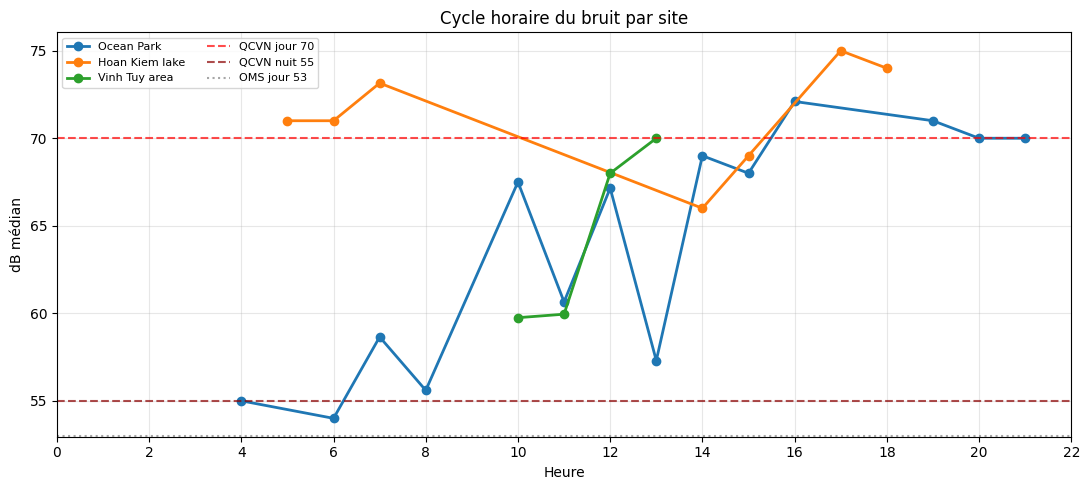

In [2]:
# === Tâche 1a : cycle horaire par site (patterns sur une journée) ===
QCVN_D, QCVN_N, WHO_D, WHO_N = 70, 55, 53, 45
fig, ax = plt.subplots(figsize=(11, 5))
for s in df.site.unique():
    g = df[df.site == s].groupby('hour')['noise_dB'].median()
    ax.plot(g.index, g.values, marker='o', lw=2, label=s)
ax.axhline(QCVN_D, ls='--', c='red', alpha=.7, label='QCVN jour 70')
ax.axhline(QCVN_N, ls='--', c='darkred', alpha=.7, label='QCVN nuit 55')
ax.axhline(WHO_D, ls=':', c='gray', alpha=.7, label='OMS jour 53')
ax.set_xlabel('Heure'); ax.set_ylabel('dB médian'); ax.set_xticks(range(0, 24, 2))
ax.set_title('Cycle horaire du bruit par site'); ax.legend(fontsize=8, ncol=2); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig('../outputs/maps/analyse_1_horaire.png', dpi=130); plt.show()

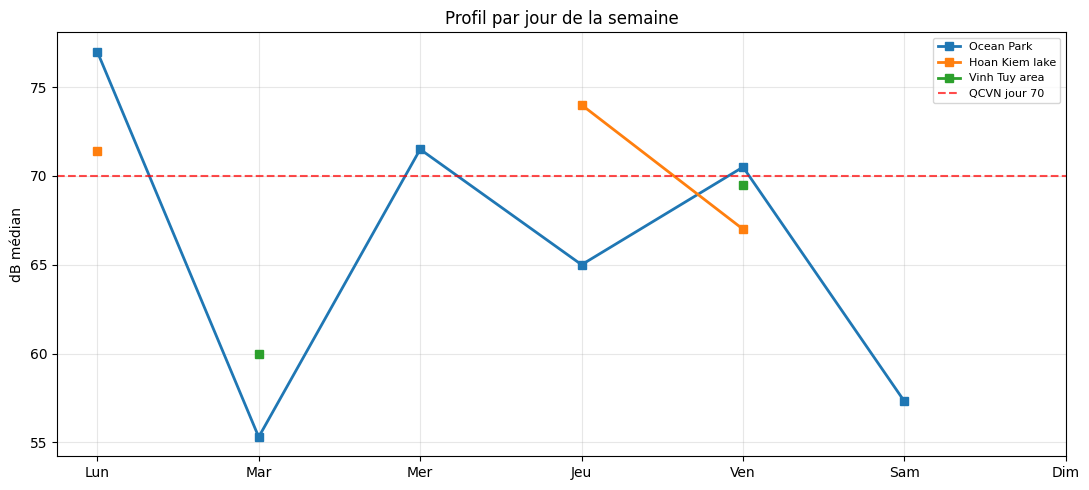

In [3]:
# === Tâche 1b : profil par jour de la semaine ===
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fr = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
df['dayname'] = df['timestamp'].dt.day_name()
fig, ax = plt.subplots(figsize=(11, 5))
for s in df.site.unique():
    g = df[df.site == s].groupby('dayname')['noise_dB'].median().reindex(order)
    ax.plot(range(7), g.values, marker='s', lw=2, label=s)
ax.axhline(QCVN_D, ls='--', c='red', alpha=.7, label='QCVN jour 70')
ax.set_xticks(range(7)); ax.set_xticklabels(fr); ax.set_ylabel('dB médian')
ax.set_title('Profil par jour de la semaine'); ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig('../outputs/maps/analyse_2_jour.png', dpi=130); plt.show()

/var/folders/l5/7bswhdj12r5f7t_fnxgz2gs40000gn/T/ipykernel_69114/2295184736.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a1.boxplot(data, labels=['Transport/autre', 'Construction'])


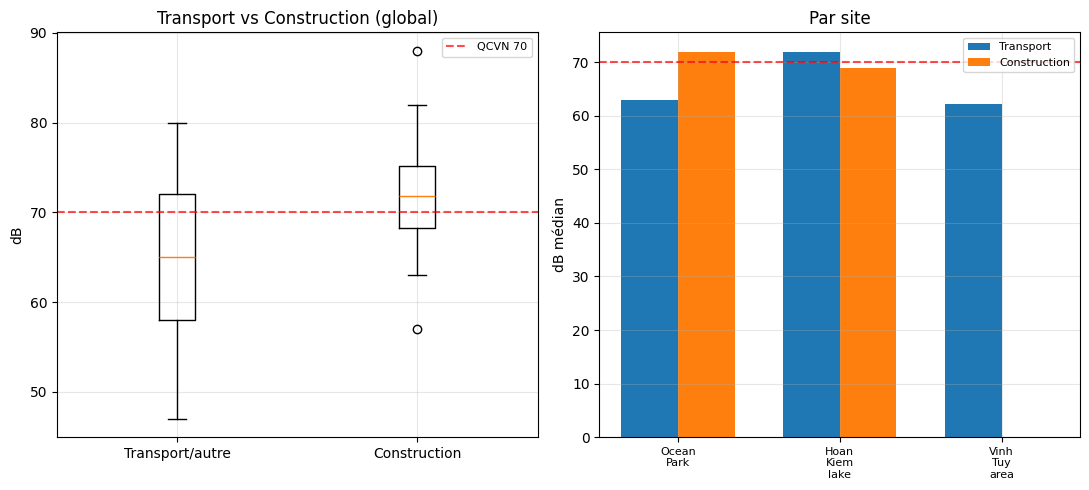

In [4]:
# === Tâche 2 : transport vs construction (côte à côte) ===
df['is_constr'] = df['class'].astype(str).str.contains('construction', case=False)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 5))
data = [df[~df.is_constr].noise_dB.dropna(), df[df.is_constr].noise_dB.dropna()]
a1.boxplot(data, labels=['Transport/autre', 'Construction'])
a1.axhline(QCVN_D, ls='--', c='red', alpha=.7, label='QCVN 70'); a1.set_ylabel('dB')
a1.set_title('Transport vs Construction (global)'); a1.legend(fontsize=8); a1.grid(alpha=.3)
sites = df.site.unique(); w = .35
for i, s in enumerate(sites):
    sub = df[df.site == s]
    a2.bar(i-w/2, sub[~sub.is_constr].noise_dB.median(), w, color='#1f77b4', label='Transport' if i == 0 else '')
    cv = sub[sub.is_constr].noise_dB.median()
    a2.bar(i+w/2, 0 if np.isnan(cv) else cv, w, color='#ff7f0e', label='Construction' if i == 0 else '')
a2.axhline(QCVN_D, ls='--', c='red', alpha=.7); a2.set_xticks(range(len(sites)))
a2.set_xticklabels([s.replace(' ', chr(10)) for s in sites], fontsize=8)
a2.set_ylabel('dB médian'); a2.set_title('Par site'); a2.legend(fontsize=8); a2.grid(alpha=.3)
plt.tight_layout(); plt.savefig('../outputs/maps/analyse_3_type.png', dpi=130); plt.show()

/var/folders/l5/7bswhdj12r5f7t_fnxgz2gs40000gn/T/ipykernel_69114/2897131848.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pe = df.groupby('hour').apply(


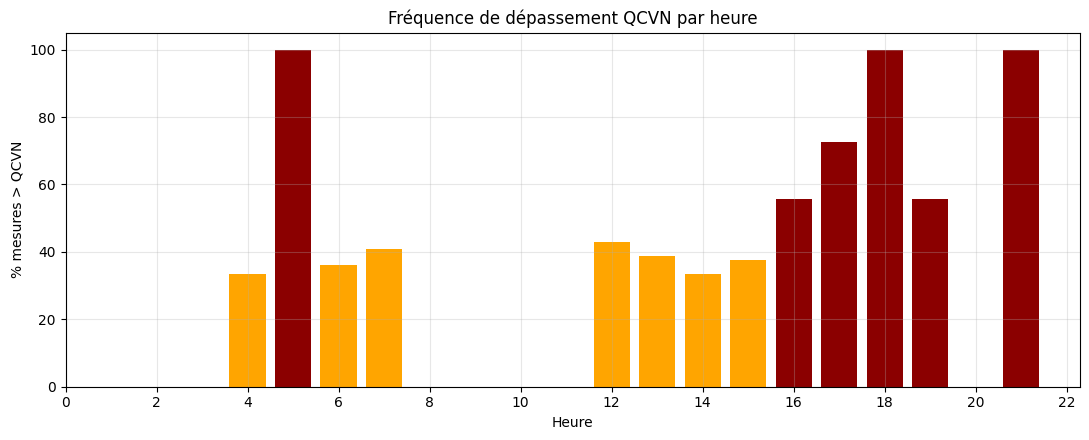

Pic de bruit : 17h (75 dB) | plus calme : 4h (55 dB)
Dépassement QCVN global : 38% des mesures

=== Dépassements QCVN par site x période ===


/var/folders/l5/7bswhdj12r5f7t_fnxgz2gs40000gn/T/ipykernel_69114/2897131848.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summ = df.groupby(['site', 'period']).apply(lambda g: pd.Series({


n  dB_median  pct_depassement  severite_moy_dB
site           period                                                    
Hoan Kiem lake day      38.0       71.9             68.4              4.6
               night     6.0       71.0            100.0             15.2
Ocean Park     day     144.0       65.0             32.6              5.0
               night     4.0       57.0             50.0              9.5
Vinh Tuy area  day      28.0       62.3              7.1              2.0

In [5]:
# === Tâches 3+4 : dépassements normes, périodes de pointe, fréquence/sévérité ===
df['period'] = np.where((df.hour >= 21) | (df.hour < 6), 'night', 'day')
df['limit'] = np.where(df.period == 'night', QCVN_N, QCVN_D)
df['exceeds'] = df.noise_dB > df['limit']

# fréquence de dépassement par heure (identifie les périodes de pointe)
fig, ax = plt.subplots(figsize=(11, 4.5))
pe = df.groupby('hour').apply(
    lambda g: (g.noise_dB > np.where((g.hour >= 21) | (g.hour < 6), QCVN_N, QCVN_D)).mean() * 100)
ax.bar(pe.index, pe.values, color=['darkred' if v > 50 else 'orange' if v > 0 else 'green' for v in pe.values])
ax.set_xlabel('Heure'); ax.set_ylabel('% mesures > QCVN'); ax.set_xticks(range(0, 24, 2))
ax.set_title('Fréquence de dépassement QCVN par heure'); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig('../outputs/maps/analyse_4_depassement.png', dpi=130); plt.show()

peak = df.groupby('hour').noise_dB.median()
print(f'Pic de bruit : {peak.idxmax()}h ({peak.max():.0f} dB) | plus calme : {peak.idxmin()}h ({peak.min():.0f} dB)')
print(f'Dépassement QCVN global : {100*df.exceeds.mean():.0f}% des mesures')

# tableau fréquence + sévérité par site x période
summ = df.groupby(['site', 'period']).apply(lambda g: pd.Series({
    'n': len(g), 'dB_median': g.noise_dB.median(),
    'pct_depassement': 100 * g.exceeds.mean(),
    'severite_moy_dB': (g.noise_dB - g['limit'])[g.exceeds].mean()})).round(1)
summ.to_csv('../outputs/hanoi_exceedances.csv')
print('\n=== Dépassements QCVN par site x période ==='); summ

In [6]:
# ---- Sauvegarde finale : input du notebook 08 (calibration du modèle) ----
out = pfd.save_measurements(df)
print(f'{len(df)} mesures → {out}')
print('Prochaine étape : notebook 08 (transfer learning + carte de bruit)')

220 mesures → /Users/phocidae/Desktop/VinUni/noise-modelling-hanoi/data/raw/hanoi/measurements.csv
Prochaine étape : notebook 08 (transfer learning + carte de bruit)


In [7]:
# Carte des points de mesure (fond OpenStreetMap)
import folium

m = folium.Map(location=[df.latitude.mean(), df.longitude.mean()],
               zoom_start=16, tiles='OpenStreetMap')

def color(db):
    return 'green' if db < 60 else 'orange' if db < 70 else 'red' if db < 80 else 'darkred'

for _, r in df.iterrows():
    folium.CircleMarker(
        [r.latitude, r.longitude], radius=7,
        color=color(r.noise_dB), fill=True, fill_opacity=0.9,
        popup=f"{r.noise_dB:.0f} dB — {r['class']}<br>{r.timestamp:%d/%m %H:%M} — {r.collector}",
        tooltip=f'{r.noise_dB:.0f} dB',
    ).add_to(m)

legend = '''<div style="position:fixed;bottom:20px;left:20px;z-index:9999;background:white;
padding:10px;border:1px solid #888;border-radius:6px;font-size:13px">
<b>Mesures terrain (n=%d)</b><br>
<span style="color:green">&#9679;</span> &lt; 60 dB &nbsp;
<span style="color:orange">&#9679;</span> 60-70 &nbsp;
<span style="color:red">&#9679;</span> 70-80 &nbsp;
<span style="color:darkred">&#9679;</span> &gt; 80</div>''' % len(df)
m.get_root().html.add_child(folium.Element(legend))
m.save('../outputs/maps/hanoi_field_points.html')
m